In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
churn_data = pd.read_csv("Telco_Customer_Churn.csv")
churn_data
sales_data=pd.read_csv("Superstore.csv",encoding="latin1")
#sales_data

In [3]:
#Churn data
print("Shape:",churn_data.shape)
print("Columns:",churn_data.columns.tolist())
print("First 5 rows:",churn_data.head())

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
First 5 rows:    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1 

In [4]:
#Sales data
print("Shape:",sales_data.shape)
print("Columns:",sales_data.columns.tolist())
print("First 5 rows:",sales_data.head())

Shape: (9994, 21)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
First 5 rows:    Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2 

In [5]:
#basic info
print("Churn dataset info:",churn_data.info())
print("Sales dataset info:",sales_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
#Missing values
print("Missing data in churn data")
print(churn_data.isnull().sum())

print("Missing data in sales data")
print(sales_data.isnull().sum())

Missing data in churn data
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Missing data in sales data
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [7]:
print("Churn dataset stats:",churn_data.describe())
print("sales dataset stats:",sales_data.describe())

Churn dataset stats:        SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000
sales dataset stats:             Row ID   Postal Code         Sales     Quantity     Discount  \
count  9994.000000   9994.000000   9994.000000  9994.000000  9994.000000   
mean   4997.500000  55190.379428    229.858001     3.789574     0.156203   
std    2885.163629  32063.693350    623.245101     2.225110     0.206452   
min       1.000000   1040.000000      0.444000     1.000000     0.000000   
25%    2499.250000  23223.000000     17.280000     2.000000     0.000000   
50%    4997.500000  56430.500000     54.490000     3

In [8]:
#Cleaning Churn Dataset

#MAke a copy
churn=churn_data.copy()

#Fix total charges - to numbers
churn["TotalCharges"]=pd.to_numeric(churn["TotalCharges"],errors="coerce")
#convert target column to binary 
churn["Churn"]=churn["Churn"].map({"Yes":1,"No":0})
#Drop customer id 
churn=churn.drop("customerID",axis=1)

print("Churn data set cleaned")
print("shape after cleaning:",churn.shape)
churn.head()

Churn data set cleaned
shape after cleaning: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [9]:
#check churn balance

print("Churn Distribution:")
print(churn["Churn"].value_counts())
print("churn rate:",churn["Churn"].mean()*100,"%")

Churn Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
churn rate: 26.536987079369588 %


In [10]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

# Find all categorical columns
cat_cols=churn.select_dtypes(include="object").columns.tolist()

#encode each one
for cols in cat_cols:
    churn[cols]=le.fit_transform(churn[cols])

churn.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [11]:
sales_data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [12]:
sales=sales_data.copy()

sales.columns=sales.columns.str.strip()

#convert order data and shit date to datetime
sales["Order Date"]=pd.to_datetime(sales["Order Date"])
sales["Ship Date"]=pd.to_datetime(sales["Ship Date"])

#Extract useful info
sales["Order Year"]=sales["Order Date"].dt.year
sales["Order Month"]=sales["Order Date"].dt.month
sales["Order Quarter"]=sales["Order Date"].dt.quarter

cate_cols=sales.select_dtypes(include="object").columns.tolist()
for col in cate_cols:
    print(f"{col} -> {sales[col].nunique()} Unique values : {sales[col].unique()[:3]}")

Order ID -> 5009 Unique values : ['CA-2016-152156' 'CA-2016-138688' 'US-2015-108966']
Ship Mode -> 4 Unique values : ['Second Class' 'Standard Class' 'First Class']
Customer ID -> 793 Unique values : ['CG-12520' 'DV-13045' 'SO-20335']
Customer Name -> 793 Unique values : ['Claire Gute' 'Darrin Van Huff' "Sean O'Donnell"]
Segment -> 3 Unique values : ['Consumer' 'Corporate' 'Home Office']
Country -> 1 Unique values : ['United States']
City -> 531 Unique values : ['Henderson' 'Los Angeles' 'Fort Lauderdale']
State -> 49 Unique values : ['Kentucky' 'California' 'Florida']
Region -> 4 Unique values : ['South' 'West' 'Central']
Product ID -> 1862 Unique values : ['FUR-BO-10001798' 'FUR-CH-10000454' 'OFF-LA-10000240']
Category -> 3 Unique values : ['Furniture' 'Office Supplies' 'Technology']
Sub-Category -> 17 Unique values : ['Bookcases' 'Chairs' 'Labels']
Product Name -> 1850 Unique values : ['Bush Somerset Collection Bookcase'
 'Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back'

In [13]:
print(sales.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order Year', 'Order Month', 'Order Quarter']


In [14]:
# Columns to KEEP as text → used for dashboard filters & charts
sales.drop(columns=["Row ID"], inplace=True)
sales.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Quarter
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,4
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,4
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,4
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,4


In [15]:
dashboard_cols=['Ship Mode', 'Segment', 'City', 'State','Region', 'Category', 'Sub-Category']

sales_dashboard=sales.copy()
sales_ml=sales.copy()

for col in dashboard_cols:
    sales_ml[col]=le.fit_transform(sales_ml[col])


sales_dashboard

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Quarter
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,4
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,4
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,4
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,...,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,2014,1,1
9990,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,2017,2,1
9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,2017,2,1
9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,...,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,2017,2,1


In [16]:
sales_ml["Ship Mode"] = le.fit_transform(sales_dashboard["Ship Mode"])
print(le.classes_)

['First Class' 'Same Day' 'Second Class' 'Standard Class']


In [17]:
for i, value in enumerate(le.classes_):
    print(i, "->", value)

0 -> First Class
1 -> Same Day
2 -> Second Class
3 -> Standard Class


In [18]:
churn.dropna(subset=["TotalCharges"],inplace=True)
print(churn.isnull().sum())
print(sales.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Order Year       0
Order Month      0
Order Quarter    0
dtype: int64


In [19]:
churn.to_csv("../data/processed/churn_cleaned.csv",index=False)
sales.to_csv("../data/processed/sales_cleaned.csv",index=False)

In [20]:
data=pd.read_csv("../data/processed/churn_cleaned.csv")
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [21]:
data1=pd.read_csv("../data/processed/sales_cleaned.csv")
data1.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Quarter
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,4
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,4
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,4
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,4


In [22]:
print("Churn Shape:", churn.shape)
print("Sales Shape:", sales.shape)
print("Churn rate:",churn["Churn"].mean()*100,"%")
print(f"Revenue: ${sales["Sales"].sum():,.2f}")
print(f"Profit: ${sales["Profit"].sum():,.2f}")
print(f"Date range: {sales["Order Date"].min().date()} -> {sales["Order Date"].max().date()}")

Churn Shape: (7032, 20)
Sales Shape: (9994, 23)
Churn rate: 26.578498293515356 %
Revenue: $2,297,200.86
Profit: $286,397.02
Date range: 2014-01-03 -> 2017-12-30


In [23]:
churn=pd.read_csv("../data/processed/churn_cleaned.csv")
sales=pd.read_csv("../data/processed/sales_cleaned.csv")

In [24]:
#Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]=(10,8)
plt.rcParams["font.size"]=12

print("Datasets loaded and ready for EDA")
print(f"Churn : {churn.shape} | Sales : {sales.shape}")

Datasets loaded and ready for EDA
Churn : (7032, 20) | Sales : (9994, 23)


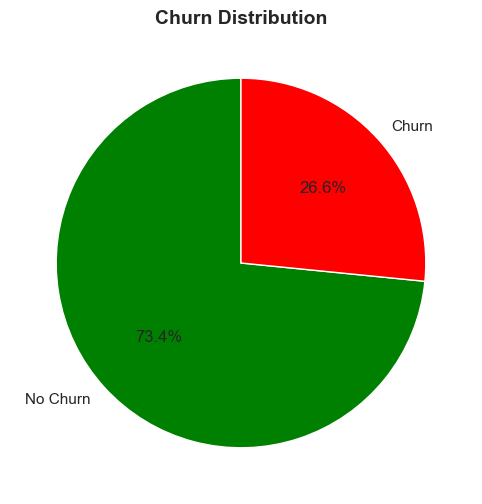

In [25]:
#Chart 1 - Churn distribution
churn_counts=churn["Churn"].value_counts()
#Piechart
plt.figure(figsize=(10,6))
plt.pie(
    churn_counts,
    labels=["No Churn","Churn"],
    autopct="%1.1f%%",
    colors=["green","red"],
    startangle=90
)
plt.title("Churn Distribution",fontsize=14,fontweight="bold")
plt.savefig("../data/processed/saved_outputs/pie_churn_distribution.png",dpi=150)

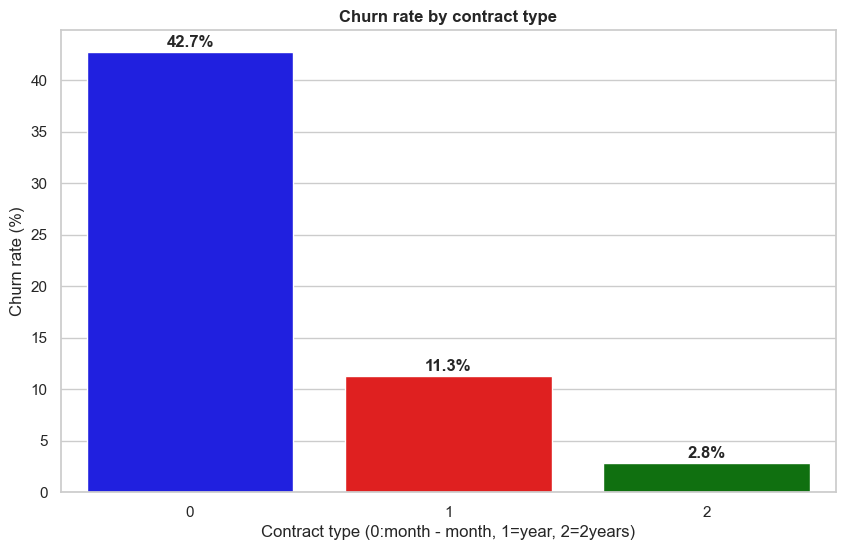

In [26]:
#Chart 2
contract_churn=churn.groupby("Contract")["Churn"].mean() * 100

plt.figure(figsize=(10,6))
#Bar chart 
sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values,
    hue=contract_churn.index,
    palette=["Blue","Red","Green"],
    legend=False
)
plt.title("Churn rate by contract type",fontsize=12,fontweight="bold")
plt.xlabel("Contract type (0:month - month, 1=year, 2=2years)")
plt.ylabel("Churn rate (%)")

# Add value labels on bars
for i,v in enumerate(contract_churn.values):
    plt.text(i,v + 0.5, f"{v:.1f}%", ha="center",fontweight="bold")

plt.savefig("../data/processed/saved_outputs/bar_contract_churn.png",dpi=150)

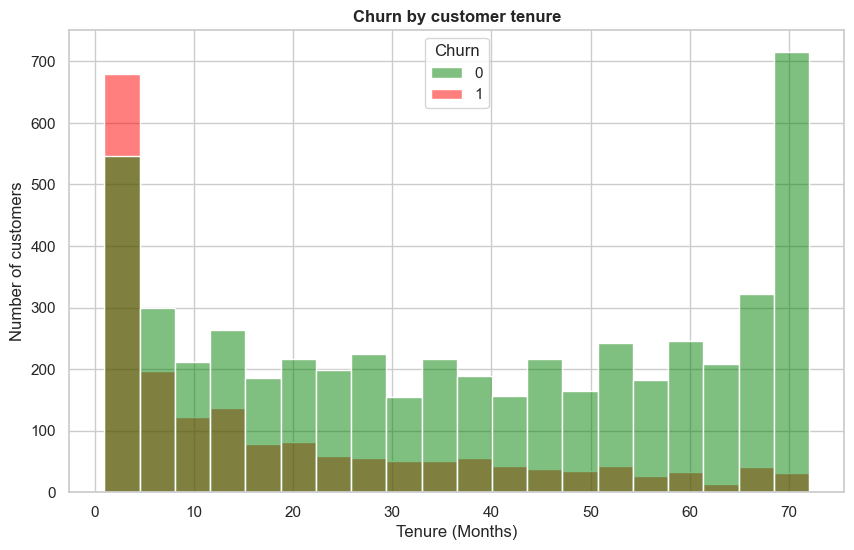

In [27]:
#Histogram

plt.figure(figsize=(10,6))
sns.histplot(
    data=churn,
    x="tenure",
    hue="Churn",
    bins=20,
    palette={0:"green",1:"red"}
)

plt.title("Churn by customer tenure",fontsize=12,fontweight="bold")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of customers")
plt.savefig("../data/processed/saved_outputs/hist_churn_tenure.png",dpi=150)
plt.show()

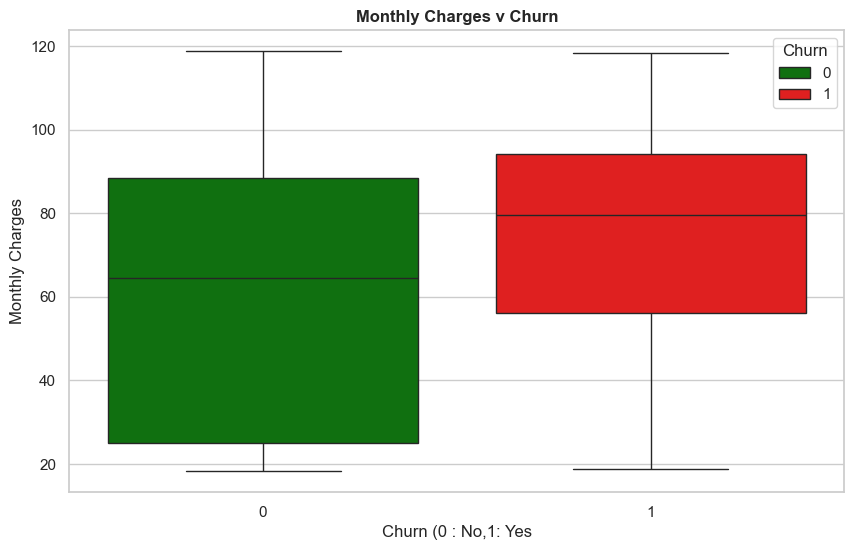

In [28]:
#boxplot - monthly cost v churn

plt.figure(figsize=(10,6))
sns.boxplot(
    data=churn,
    x='Churn',
    y='MonthlyCharges',
    hue="Churn",
    palette={0:'green', 1: 'red'}
)
plt.title("Monthly Charges v Churn",fontsize=12,fontweight="bold")
plt.xlabel("Churn (0 : No,1: Yes")
plt.ylabel("Monthly Charges")
plt.savefig("../data/processed/saved_outputs/boxplot_charges_churn.png",dpi=150)
plt.show()


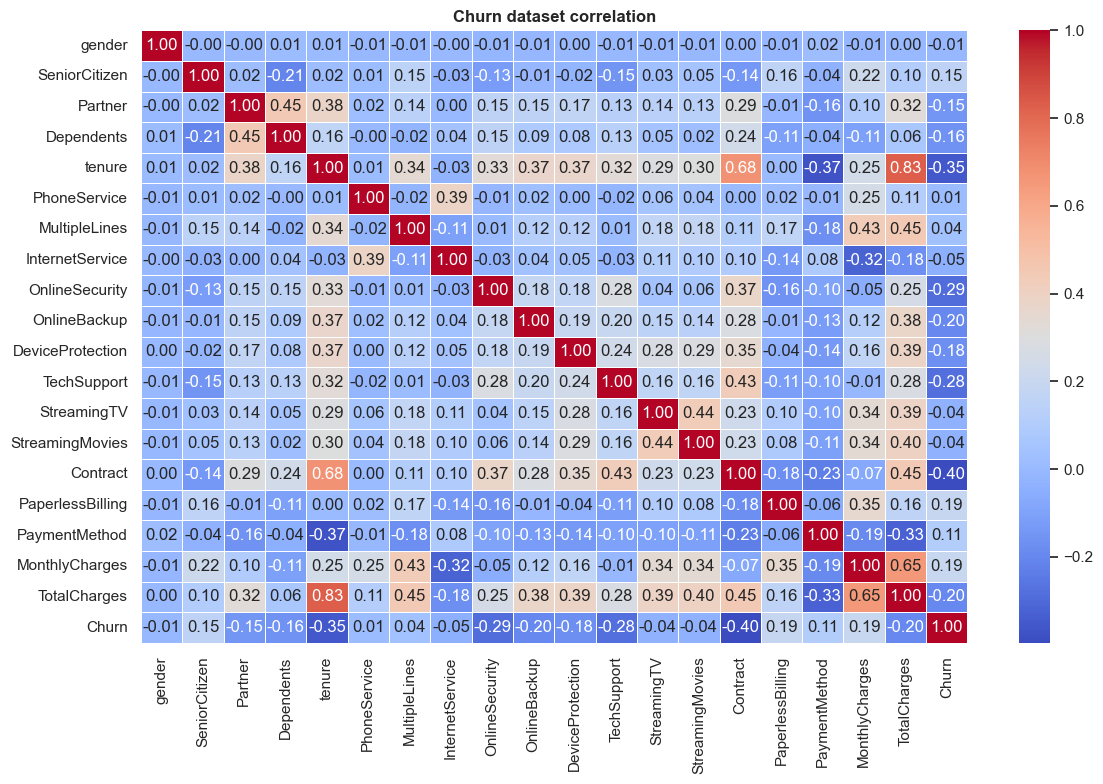

In [29]:
plt.figure(figsize=(12,6+2))
#Heatmap
sns.heatmap(
    churn.corr(),
    annot=True,
    fmt='.2f',
    cmap="coolwarm",
    linewidth=0.5
)
plt.title("Churn dataset correlation",fontsize=12,fontweight="bold")
plt.savefig("../data/processed/saved_outputs/corr_churn.png",dpi=150)
plt.tight_layout()
plt.show()
    

SALES CHARTS

C:\Users\jashi\AppData\Local\Temp\ipykernel_13888\1585536139.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


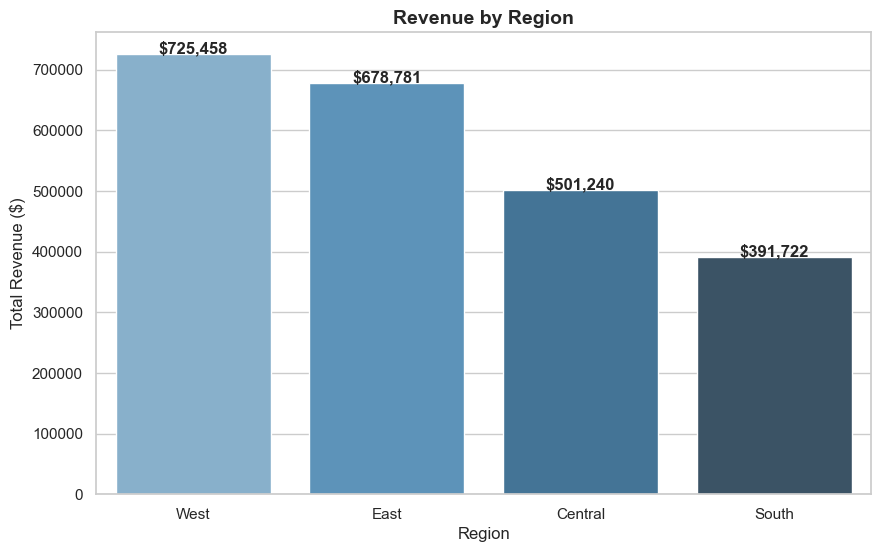

In [30]:
plt.figure(figsize=(10,6))

regional_sales=sales.groupby("Region")["Sales"].sum().sort_values(ascending=False)

sns.barplot(
    x=regional_sales.index,
    y=regional_sales.values,
    palette='Blues_d'
)

plt.title('Revenue by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Revenue ($)')

for i,v in enumerate(regional_sales.values):
    plt.text(i,v+1000,f"${v:,.0f}",ha="center",fontweight="bold")

plt.savefig("../data/processed/saved_outputs/Sales_region.png",dpi=150)
plt.show()

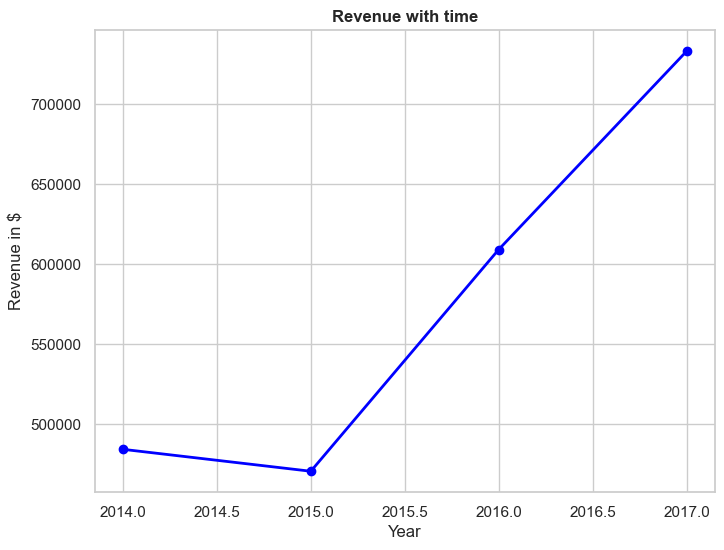

In [31]:
#Yearly sales
plt.figure(figsize=(8,6))

yearly_sales=sales.groupby("Order Year")["Sales"].sum()

plt.plot(
    yearly_sales.index,
    yearly_sales.values,
    color="blue",
    linewidth=2,
    marker="o"
)
plt.title("Revenue with time",fontsize=12,fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Revenue in $")
plt.savefig("../data/processed/saved_outputs/yearly_sales.png",dpi=150)
plt.show()
    

C:\Users\jashi\AppData\Local\Temp\ipykernel_13888\3841568487.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


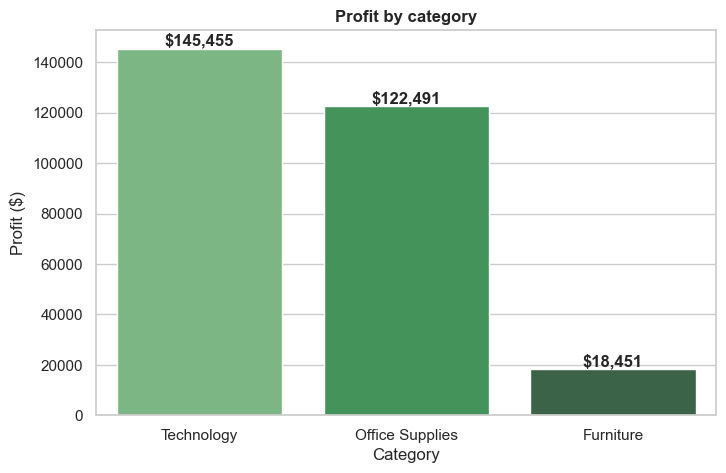

In [32]:
#Profit by category
plt.figure(figsize=(8,5))

category_profit=sales.groupby("Category")["Profit"].sum().sort_values(ascending=False)

sns.barplot(
    x=category_profit.index,
    y=category_profit.values,
    palette="Greens_d"
)
plt.title("Profit by category",fontsize=12,fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Profit ($)")

for i,v in enumerate(category_profit.values):
    plt.text(i,v,f"${v:,.0f}",ha="center",va="bottom",fontweight="bold")

plt.savefig("../data/processed/saved_outputs/profit_category.png",dpi=150)
plt.show()

C:\Users\jashi\AppData\Local\Temp\ipykernel_13888\4270883369.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


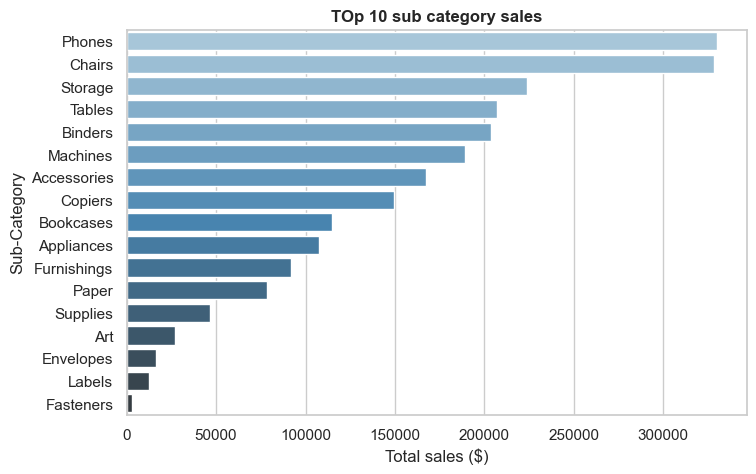

In [33]:
#top 10 subcategory by sales
plt.figure(figsize=(8,5))

subcat_cales=sales.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

sns.barplot(
    x=subcat_cales.values,
    y=subcat_cales.index,
    palette="Blues_d"
)

plt.title("TOp 10 sub category sales",fontsize=12,fontweight="bold")
plt.xlabel("Total sales ($)")
plt.ylabel("Sub-Category")

plt.savefig("../data/processed/saved_outputs/10_subcat_cales.png",dpi=150)
plt.show()
    

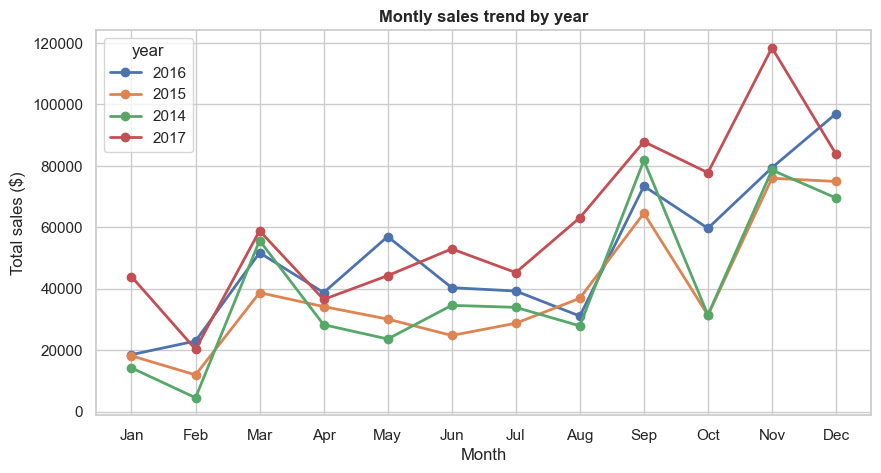

In [34]:
#Monthly Sales Trend by Year (Line Chart)
plt.figure(figsize=(10,5))

for year in sales["Order Year"].unique():
    yearly_data=sales[sales["Order Year"]==year]
    monthly_data=yearly_data.groupby("Order Month")["Sales"].sum()
    plt.plot(
        monthly_data.index,
        monthly_data.values,
        marker="o",
        linewidth=2,
        label=str(year)
    )

plt.title("Montly sales trend by year",fontsize=12,fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total sales ($)")
plt.xticks(range(1,13),['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title="year")

plt.savefig("../data/processed/saved_outputs/monthly_sales.png",dpi=150)
plt.show()
        
        


In [35]:
churn=pd.read_csv("../data/processed/churn_cleaned.csv")
sales=pd.read_csv("../data/processed/sales_cleaned.csv")
print("Churn")
print(churn.columns.tolist())
print("Sales")
print(sales.columns.tolist())

Churn
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Sales
['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order Year', 'Order Month', 'Order Quarter']


In [36]:
# Load fresh from raw
churn = pd.read_csv('../data/raw/Telco_Customer_Churn.csv')

# Basic cleaning
churn['TotalCharges'] = pd.to_numeric(churn['TotalCharges'], errors='coerce')
churn.dropna(subset=['TotalCharges'], inplace=True)
churn['Churn'] = churn['Churn'].map({'Yes': 1, 'No': 0})
churn.drop(columns=['customerID'], inplace=True)

# Fix numeric columns
churn['tenure'] = pd.to_numeric(churn['tenure'], errors='coerce')
churn['MonthlyCharges'] = pd.to_numeric(churn['MonthlyCharges'], errors='coerce')

# Verify
print("Tenure sample:", churn['tenure'].head(5).tolist())
print("Tenure nulls:", churn['tenure'].isnull().sum())
print("Shape:", churn.shape)

Tenure sample: [1, 34, 2, 45, 2]
Tenure nulls: 0
Shape: (7032, 20)


In [37]:
# 1. Tenure group
#churn['tenure'] = pd.to_numeric(churn['tenure'], errors='coerce')
churn["tenure_group"] = pd.cut(
    churn["tenure"],
    bins=[0,12,24,48,72],
    labels=["0-12 months","12-24 months","24-48 months","48+ months"]
)

# 2. High Value Customer Flag
churn["MonthlyCharges"]=pd.to_numeric(churn["MonthlyCharges"])
churn["high_value"]=(churn["MonthlyCharges"] > churn["MonthlyCharges"].median()).astype(int)
# 3. Charges Ratio
churn["charges_ratio"]=churn["TotalCharges"]/(churn["tenure"]+1)

# 4. Service Count
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup','DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
churn["service_count"]=churn[service_cols].apply(
    lambda x: (x=="Yes").sum(),axis=1
)

print("Churn features added")
print(churn[['tenure', 'tenure_group', 'high_value', 'charges_ratio', 'service_count']].head())
    

Churn features added
   tenure  tenure_group  high_value  charges_ratio  service_count
0       1   0-12 months           0      14.925000              1
1      34  24-48 months           0      53.985714              3
2       2   0-12 months           0      36.050000              3
3      45  24-48 months           0      40.016304              3
4       2   0-12 months           1      50.550000              1


In [38]:
#conver to date 
sales["Order Date"]=pd.to_datetime(sales["Order Date"])
sales['Ship Date']=pd.to_datetime(sales['Ship Date'])

#Profit margin (%)
sales["profit_margin"]=(sales["Profit"]/sales["Sales"]*100).round(2)

#days to ship
sales["days_to_ship"]=(sales["Ship Date"]-sales["Order Date"]).dt.days

#Revenue per unit 
sales["revenue_per_unit"]=(sales["Sales"]/sales["Quantity"]).round(2)

print("Sales features added")
print(sales[['Sales', 'Profit', 'profit_margin', 'days_to_ship', 'revenue_per_unit']].head())

Sales features added
      Sales    Profit  profit_margin  days_to_ship  revenue_per_unit
0  261.9600   41.9136          16.00             3            130.98
1  731.9400  219.5820          30.00             3            243.98
2   14.6200    6.8714          47.00             4              7.31
3  957.5775 -383.0310         -40.00             7            191.52
4   22.3680    2.5164          11.25             7             11.18


In [39]:
churn.to_csv('../data/processed/churn_featured.csv', index=False)
sales.to_csv('../data/processed/sales_featured.csv', index=False)

print("churn_featured.csv saved")
print("sales_featured.csv saved")
print(f"\nChurn shape: {churn.shape}")
print(f"Sales shape: {sales.shape}")

churn_featured.csv saved
sales_featured.csv saved

Churn shape: (7032, 24)
Sales shape: (9994, 26)


In [40]:
print("4.Feature Engineering")
print("\nChurn New Features:")
print(" → tenure_group    : Customer grouped by tenure")
print("  → high_value      : 1 if above median monthly charges")
print("  → charges_ratio   : Total charges per month")
print("  → service_count   : Number of services subscribed")
print("\nSales New Features:")
print("  → profit_margin   : Profit as % of sales")
print("  → days_to_ship    : Delivery speed in days")
print("  → revenue_per_unit: Sales per quantity")

4.Feature Engineering

Churn New Features:
 → tenure_group    : Customer grouped by tenure
  → high_value      : 1 if above median monthly charges
  → charges_ratio   : Total charges per month
  → service_count   : Number of services subscribed

Sales New Features:
  → profit_margin   : Profit as % of sales
  → days_to_ship    : Delivery speed in days
  → revenue_per_unit: Sales per quantity


In [41]:
print("Tenure Stats:")
print(churn['tenure'].describe())

print("\nTenure Value Counts (first 10):")
print(churn['tenure'].value_counts().sort_index().head(10))

print("\nMin tenure:", churn['tenure'].min())
print("Max tenure:", churn['tenure'].max())

Tenure Stats:
count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

Tenure Value Counts (first 10):
tenure
1     613
2     238
3     200
4     176
5     133
6     110
7     131
8     123
9     119
10    116
Name: count, dtype: int64

Min tenure: 1
Max tenure: 72


In [42]:
print("Tenure dtype:", churn['tenure'].dtype)
print("Tenure sample:", churn['tenure'].head(10).tolist())
print("Tenure nulls:", churn['tenure'].isnull().sum())
print("TotalCharges nulls:", churn['TotalCharges'].isnull().sum())

Tenure dtype: int64
Tenure sample: [1, 34, 2, 45, 2, 8, 22, 10, 28, 62]
Tenure nulls: 0
TotalCharges nulls: 0


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import joblib

In [67]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Find and encode all string columns except tenure_group
cat_cols = churn.select_dtypes(include='object').columns.tolist()
print("Encoding these columns:", cat_cols)

for col in cat_cols:
    churn[col] = le.fit_transform(churn[col].astype(str))

print("Encoding done")
print(churn.dtypes)

Encoding these columns: []
Encoding done
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
tenure_group          int64
high_value            int64
charges_ratio       float64
service_count         int64
dtype: object


In [62]:
churn=pd.read_csv("../data/processed/churn_featured.csv")
print("Shape:", churn.shape)
print("\nColumns:", churn.columns.tolist())

Shape: (7032, 24)

Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group', 'high_value', 'charges_ratio', 'service_count']


In [64]:
x=churn.drop(columns=["Churn","tenure_group"])
y=churn["Churn"]

print("X shape:",x.shape)
print("y shape:",y.shape)
print("\nChurn distribution:")
print(y.value_counts())

X shape: (7032, 22)
y shape: (7032,)

Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [65]:
#Train-test-split

X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (5625, 22)
X_test: (1407, 22)


In [87]:
#1.Logistic regression
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
log_pred=lr.predict(X_test)
log_acc=accuracy_score(y_test,log_pred)

#2.Random Forest
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
random_pred=rf.predict(X_test)
random_acc=accuracy_score(y_test,random_pred)

#3. XG Boost
xgb=XGBClassifier(random_state=42,eval_matrics="logloss")
xgb.fit(X_train,y_train)
xgb_pred=xgb.predict(X_test)
xgb_acc=accuracy_score(y_test,xgb_pred)

print("=MODEL COMPARISON=")
print(f"Logistic Regression:{log_acc*100:.2f}%")
print(f"Random Forest: {random_acc*100:.2f}%")
print(f"XG Boost: {xgb_acc*100:.2f}%")

C:\Users\jashi\Downloads\Desktop\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\jashi\Downloads\Desktop\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:36:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "eval_matrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=MODEL COMPARISON=
Logistic Regression:79.53%
Random Forest: 78.96%
XG Boost: 75.91%


In [94]:
from sklearn.metrics import classification_report, roc_auc_score

# Check ROC-AUC for all 3 — better metric than accuracy
lr_prediction=lr.predict_proba(X_test)[:,1]
lr_auc = roc_auc_score(y_test, lr_prediction)

rf_precition=rf.predict_proba(X_test)[:,1]
rf_auc = roc_auc_score(y_test, rf_precition)

xgb_prediction=xgb.predict_proba(X_test)[:,1]
xgb_auc = roc_auc_score(y_test,xgb_prediction )

print("===== ROC-AUC SCORES =====")
print(f"Logistic Regression : {lr_auc*100:.2f}%")
print(f"Random Forest       : {rf_auc*100:.2f}%")
print(f"XGBoost             : {xgb_auc*100:.2f}%")

===== ROC-AUC SCORES =====
Logistic Regression : 83.28%
Random Forest       : 81.62%
XGBoost             : 80.20%


In [95]:
joblib.dump(lr, '../models/logistic_regression.pkl')
joblib.dump(rf, '../models/random_forest.pkl')
joblib.dump(xgb, '../models/xgboost_model.pkl')

print("All models saved")
scores = {'Logistic Regression': lr_auc, 'Random Forest': rf_auc, 'XGBoost': xgb_auc}
best = max(scores,key=scores.get)
print(f"Best Model: {best} → {scores[best]*100:.2f}%")

All models saved
Best Model: Logistic Regression → 83.28%


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
import joblib

churn=pd.read_csv("../data/processed/churn_featured.csv")
model = joblib.load('../models/logistic_regression.pkl')

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib

# Load fresh data
churn = pd.read_csv('../data/processed/churn_featured.csv')

# Load best model
model = joblib.load('../models/logistic_regression.pkl')
print("Model loaded")

le = LabelEncoder()

# Encode ONLY non-numeric string columns except tenure_group
cat_cols = churn.select_dtypes(include='object').columns.tolist()
cat_cols = [col for col in cat_cols if col != 'tenure_group']
print("Encoding:", cat_cols)

for col in cat_cols:
    churn[col] = le.fit_transform(churn[col].astype(str))

# Prepare X and y - drop same columns as Day 5
X = churn.drop(columns=['Churn', 'tenure_group'])
y = churn['Churn']

print("X columns:", X.columns.tolist())

# Same split as Day 5
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Ready for evaluation")
print("Test samples:", X_test.shape[0])

 Model loaded
Encoding: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

X columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'high_value', 'charges_ratio', 'service_count']
Ready for evaluation
Test samples: 1407


In [26]:
print("Classification Report")
print(classification_report(y_test,y_pred,target_names=["No Churn","Churn"]))

Classification Report
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1033
       Churn       0.66      0.48      0.56       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.80      0.78      1407



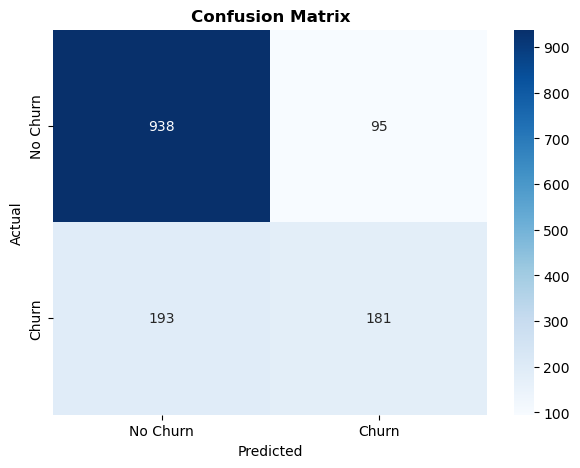

In [41]:
#Confusion Matrix

plt.figure(figsize=(7, 5))

cm=confusion_matrix(y_test,y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)
plt.title("Confusion Matrix",fontsize=12,fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../data/processed/saved_outputs/confusion_matrix.png",dpi=150)
plt.show()

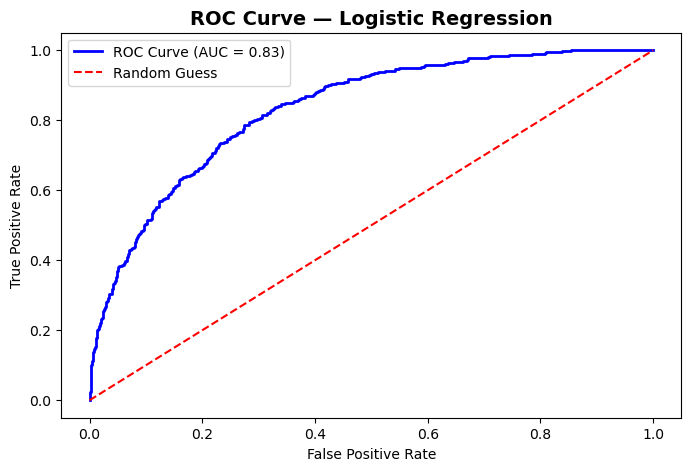

ROC-AUC Score: 83.28%


In [42]:
#ROC Curve:

plt.figure(figsize=(8, 5))

false_positive_rate, true_positive_rate, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(false_positive_rate, 
         true_positive_rate, 
         color='blue', 
         linewidth=2, 
         label=f"ROC Curve (AUC = {auc_score:.2f})"
        )
plt.plot([0, 1], [0, 1], 
         color='red', 
         linestyle='--', 
         label='Random Guess'
        )

plt.title('ROC Curve — Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.savefig('../data/processed/roc_curve.png', dpi=150)
plt.show()
print(f"ROC-AUC Score: {auc_score*100:.2f}%")

C:\Users\jashi\AppData\Local\Temp\ipykernel_21116\2694890191.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.values,y=importance.index,palette="Blues_d")


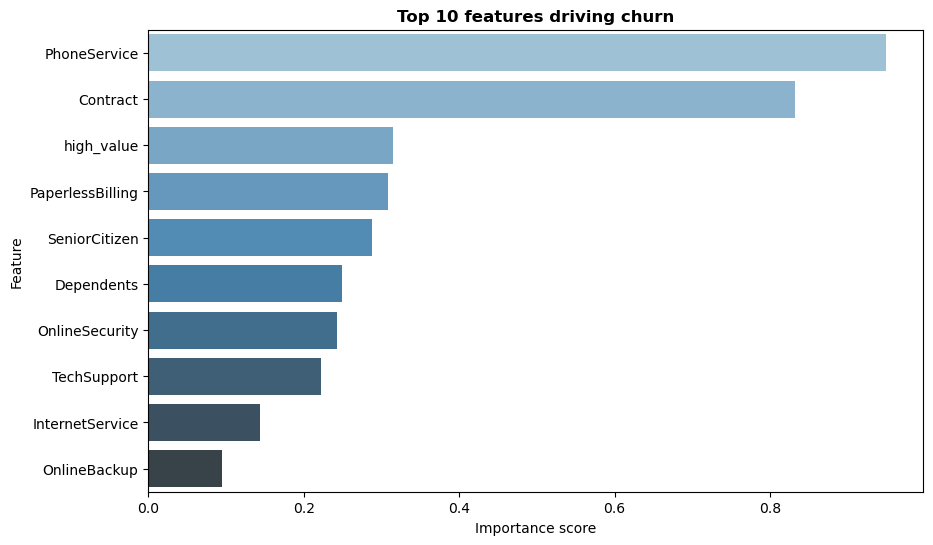

In [49]:
#Feature Importance:

plt.figure(figsize=(10, 6))

importance=pd.Series(
    abs(model.coef_[0]),
    index=X.columns
).sort_values(ascending=False).head(10)

sns.barplot(x=importance.values,y=importance.index,palette="Blues_d")
plt.title("Top 10 features driving churn",fontsize=12,fontweight="bold")
plt.xlabel("Importance score")
plt.ylabel("Feature")
plt.savefig("../data/processed/saved_outputs/10_feature_importance.png",dpi=150)
plt.show()

In [54]:
print("Model evaluation summary")
print(f"\nBest Model    : Logistic Regression")
print(f"Accuracy      : 79.53%")
print(f"ROC-AUC Score : 83.28%")
print("\nTop Churn Factors:")
for feat,score in importance.head(5).items():
    print(f"{feat}: {score:.4f}")
    

Model evaluation summary

Best Model    : Logistic Regression
Accuracy      : 79.53%
ROC-AUC Score : 83.28%

Top Churn Factors:
PhoneService: 0.9497
Contract: 0.8320
high_value: 0.3152
PaperlessBilling: 0.3089
SeniorCitizen: 0.2873
